# E-Ticaret Platformları İçin Veri Madenciliği Tabanlı Akıllı Ürün Öneri ve Kişiselleştirme Sistemi

## Vize - Proje İlerleme Raporu ve Kod Dosyaları

**Veri Seti:** [E-Commerce Data (Kaggle)](https://www.kaggle.com/datasets/carrie1/ecommerce-data) / [Online Retail (UCI ML Repository)](http://archive.ics.uci.edu/ml/datasets/Online+Retail)

**Amaç:** Bir e-ticaret sitesindeki kullanıcı davranışları analiz edilerek, Birliktelik Kuralları (Apriori Algoritması) kullanılarak "bu ürünü alanlar bunu da aldı" mantığıyla çalışan bir akıllı ürün öneri motoru tasarlamak.

**Kullanılan Yöntemler:**
- Keşifsel Veri Analizi (EDA)
- Veri Görselleştirme
- Veri Temizleme ve Ön İşleme
- Özellik Mühendisliği (Feature Engineering)
- Özellik Seçimi (Feature Selection)
- Boyut İndirgeme (Dimension Reduction)
- Apriori Algoritması ve Birliktelik Kuralları (Association Rules)


## 1. Kütüphanelerin Yüklenmesi

In [1]:
# Temel kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apriori ve birliktelik kuralları
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Makine öğrenmesi
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Ek görselleştirme
from wordcloud import WordCloud
import missingno as msno

# Ayarlar
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Tüm kütüphaneler başarıyla yüklendi!")


Matplotlib is building the font cache; this may take a moment.


Tüm kütüphaneler başarıyla yüklendi!


## 2. Veri Setinin Yüklenmesi ve İlk İnceleme

In [2]:
# Veri setini yükle
df = pd.read_csv('data/data.csv', encoding='utf-8-sig', parse_dates=['InvoiceDate'])

print("=" * 60)
print("VERİ SETİ GENEL BİLGİLERİ")
print("=" * 60)
print(f"Satır sayısı: {df.shape[0]:,}")
print(f"Sütun sayısı: {df.shape[1]}")
print(f"Bellek kullanımı: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("İlk 5 kayıt:")
df.head()


VERİ SETİ GENEL BİLGİLERİ
Satır sayısı: 541,909
Sütun sayısı: 8
Bellek kullanımı: 160.72 MB

İlk 5 kayıt:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom


In [3]:
# Veri seti bilgi özeti
print("VERİ TİPLERİ VE BOŞ DEĞERLER:")
print("-" * 50)
df.info()


VERİ TİPLERİ VE BOŞ DEĞERLER:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
# İstatistiksel özet
print("SAYISAL DEĞİŞKENLERİN İSTATİSTİKSEL ÖZETİ:")
df.describe()


SAYISAL DEĞİŞKENLERİN İSTATİSTİKSEL ÖZETİ:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,406829.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,13953.00
50%,3.00,2011-07-19 17:17:00,2.08,15152.00
75%,10.00,2011-10-19 11:27:00,4.13,16791.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1713.60


In [5]:
# Kategorik değişkenlerin özeti
print("KATEGORİK DEĞİŞKENLERİN ÖZETİ:")
print("-" * 50)
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(f"  Benzersiz değer sayısı: {df[col].nunique()}")
    print(f"  En sık değer: {df[col].mode()[0]}")
    print(f"  Eksik değer: {df[col].isnull().sum()} ({df[col].isnull().mean()*100:.2f}%)")


KATEGORİK DEĞİŞKENLERİN ÖZETİ:
--------------------------------------------------

InvoiceNo:


  Benzersiz değer sayısı: 25900
  En sık değer: 573585
  Eksik değer: 0 (0.00%)

StockCode:
  Benzersiz değer sayısı: 4070
  En sık değer: 85123A
  Eksik değer: 0 (0.00%)

Description:
  Benzersiz değer sayısı: 4223
  En sık değer: WHITE HANGING HEART T-LIGHT HOLDER
  Eksik değer: 1454 (0.27%)

Country:


  Benzersiz değer sayısı: 38
  En sık değer: United Kingdom
  Eksik değer: 0 (0.00%)


## 3. Keşifsel Veri Analizi (EDA)

### 3.1 Eksik Veri Analizi

In [6]:
# Eksik veri analizi
print("EKSİK VERİ ANALİZİ:")
print("-" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Eksik Değer': missing, 'Yüzde (%)': missing_pct})
missing_df = missing_df[missing_df['Eksik Değer'] > 0].sort_values('Yüzde (%)', ascending=False)
print(missing_df)
print(f"\nToplam eksik değer oranı: {df.isnull().sum().sum() / df.size * 100:.4f}%")


EKSİK VERİ ANALİZİ:
--------------------------------------------------


             Eksik Değer  Yüzde (%)
CustomerID        135080      24.93
Description         1454       0.27



Toplam eksik değer oranı: 3.1494%


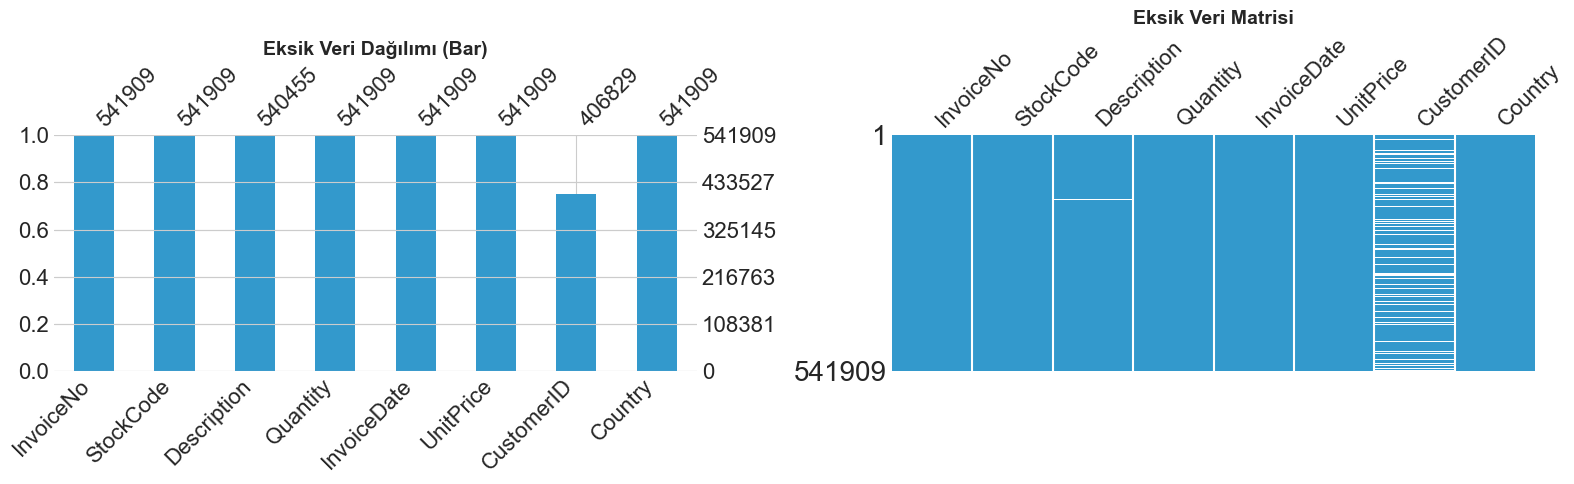

In [7]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Eksik veri çubuğu
msno.bar(df, ax=axes[0], color=(0.2, 0.6, 0.8))
axes[0].set_title('Eksik Veri Dağılımı (Bar)', fontsize=14, fontweight='bold')

# 2) Eksik veri matrisi
msno.matrix(df, ax=axes[1], color=(0.2, 0.6, 0.8))
axes[1].set_title('Eksik Veri Matrisi', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data/eksik_veri_analizi.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Ülke Bazlı Analiz

Toplam ülke sayısı: 38

En fazla işlem yapan 10 ülke:
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


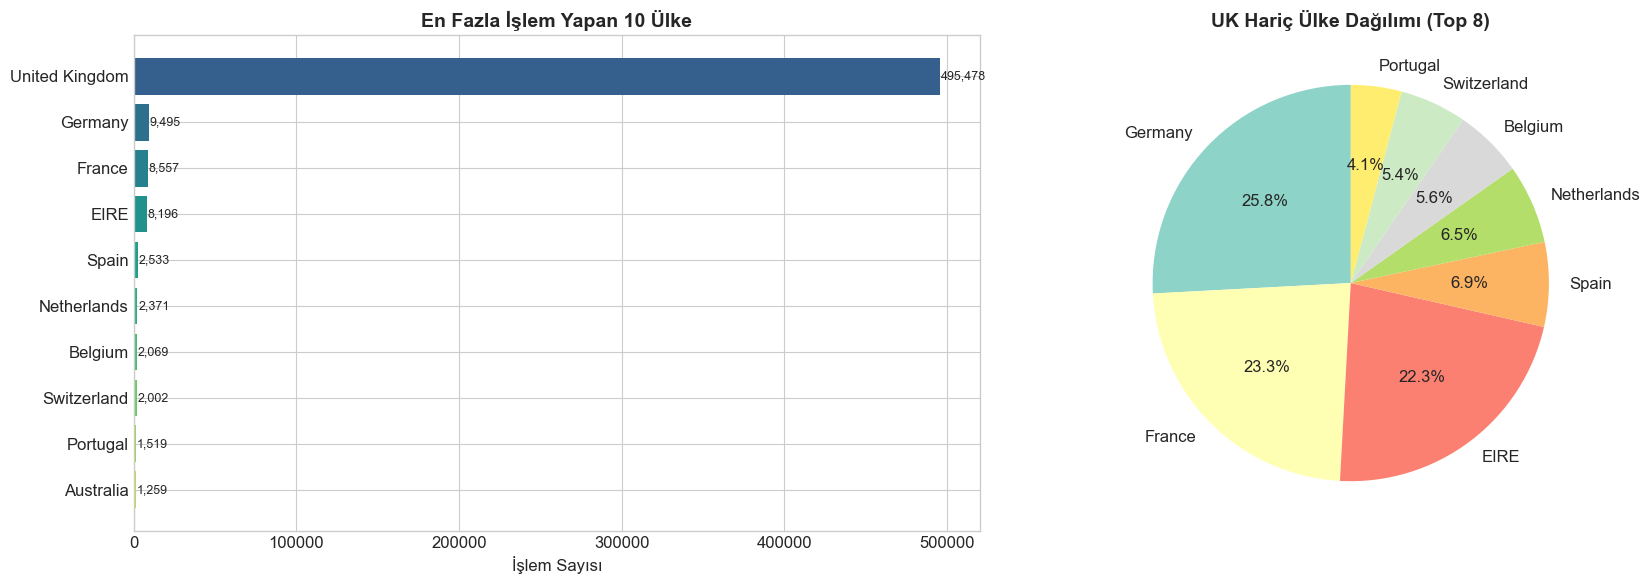

In [8]:
# Ülkelere göre işlem dağılımı
country_counts = df['Country'].value_counts()
print(f"Toplam ülke sayısı: {country_counts.shape[0]}")
print(f"\nEn fazla işlem yapan 10 ülke:")
print(country_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10 ülke bar chart
top_countries = country_counts.head(10)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_countries)))
bars = axes[0].barh(top_countries.index[::-1], top_countries.values[::-1], color=colors[::-1])
axes[0].set_xlabel('İşlem Sayısı', fontsize=12)
axes[0].set_title('En Fazla İşlem Yapan 10 Ülke', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_countries.values[::-1]):
    axes[0].text(val + 500, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

# UK hariç pie chart
non_uk = country_counts[country_counts.index != 'United Kingdom'].head(8)
axes[1].pie(non_uk.values, labels=non_uk.index, autopct='%1.1f%%',
           colors=plt.cm.Set3(np.linspace(0, 1, len(non_uk))), startangle=90)
axes[1].set_title('UK Hariç Ülke Dağılımı (Top 8)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data/ulke_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Ürün Analizi

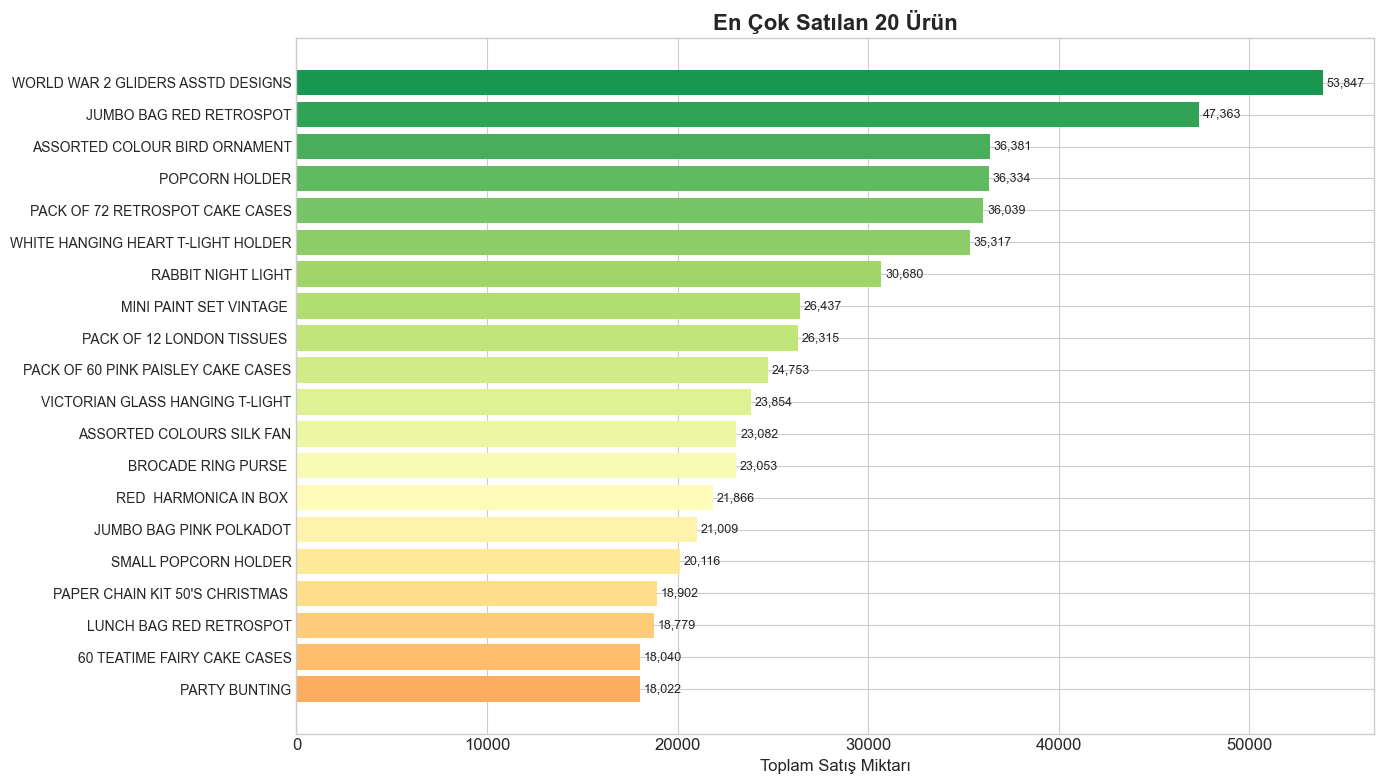

In [9]:
# En çok satılan 20 ürün
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_products)))
bars = ax.barh(range(len(top_products)), top_products.values, color=colors[::-1])
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels(top_products.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Toplam Satış Miktarı', fontsize=12)
ax.set_title('En Çok Satılan 20 Ürün', fontsize=16, fontweight='bold')
for bar, val in zip(bars, top_products.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('data/top_urunler.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Zaman Serisi Analizi

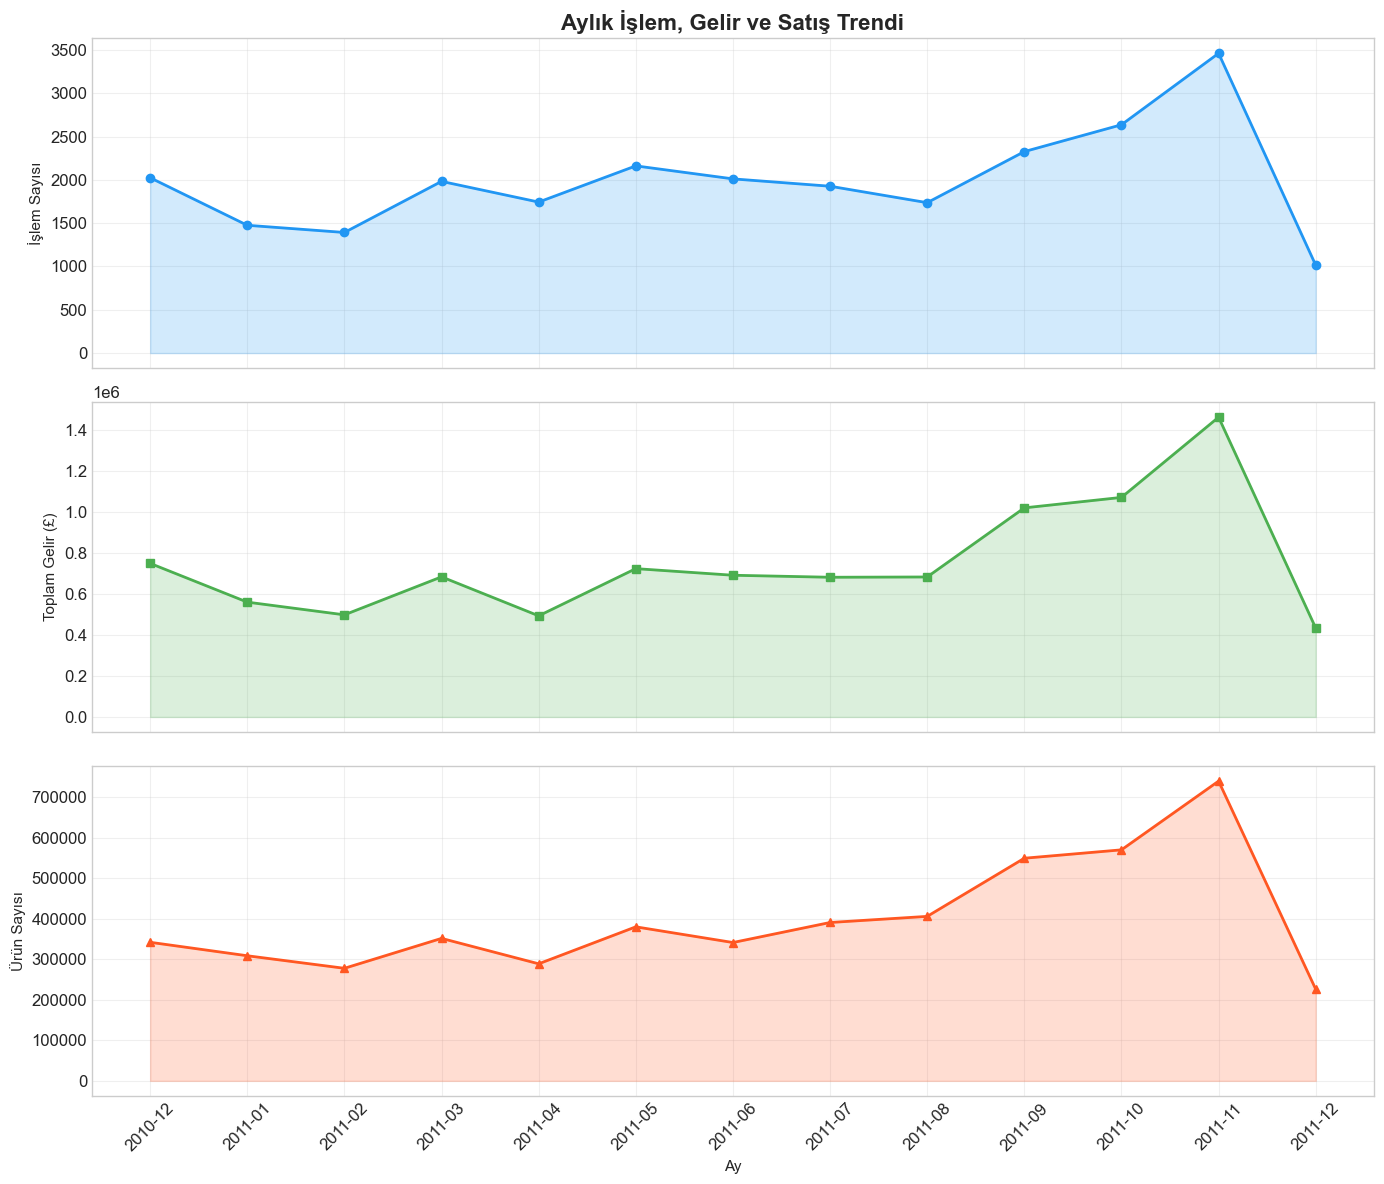

In [10]:
# Aylık satış trendi
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

monthly = df.groupby('YearMonth').agg(
    IslemSayisi=('InvoiceNo', 'nunique'),
    ToplamGelir=('TotalPrice', 'sum'),
    UrunSayisi=('Quantity', 'sum')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(monthly['YearMonth'], monthly['IslemSayisi'], 'o-', color='#2196F3', linewidth=2, markersize=6)
axes[0].fill_between(range(len(monthly)), monthly['IslemSayisi'], alpha=0.2, color='#2196F3')
axes[0].set_ylabel('İşlem Sayısı', fontsize=11)
axes[0].set_title('Aylık İşlem, Gelir ve Satış Trendi', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly['YearMonth'], monthly['ToplamGelir'], 's-', color='#4CAF50', linewidth=2, markersize=6)
axes[1].fill_between(range(len(monthly)), monthly['ToplamGelir'], alpha=0.2, color='#4CAF50')
axes[1].set_ylabel('Toplam Gelir (£)', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(monthly['YearMonth'], monthly['UrunSayisi'], '^-', color='#FF5722', linewidth=2, markersize=6)
axes[2].fill_between(range(len(monthly)), monthly['UrunSayisi'], alpha=0.2, color='#FF5722')
axes[2].set_ylabel('Ürün Sayısı', fontsize=11)
axes[2].set_xlabel('Ay', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/aylik_trend.png', dpi=150, bbox_inches='tight')
plt.show()


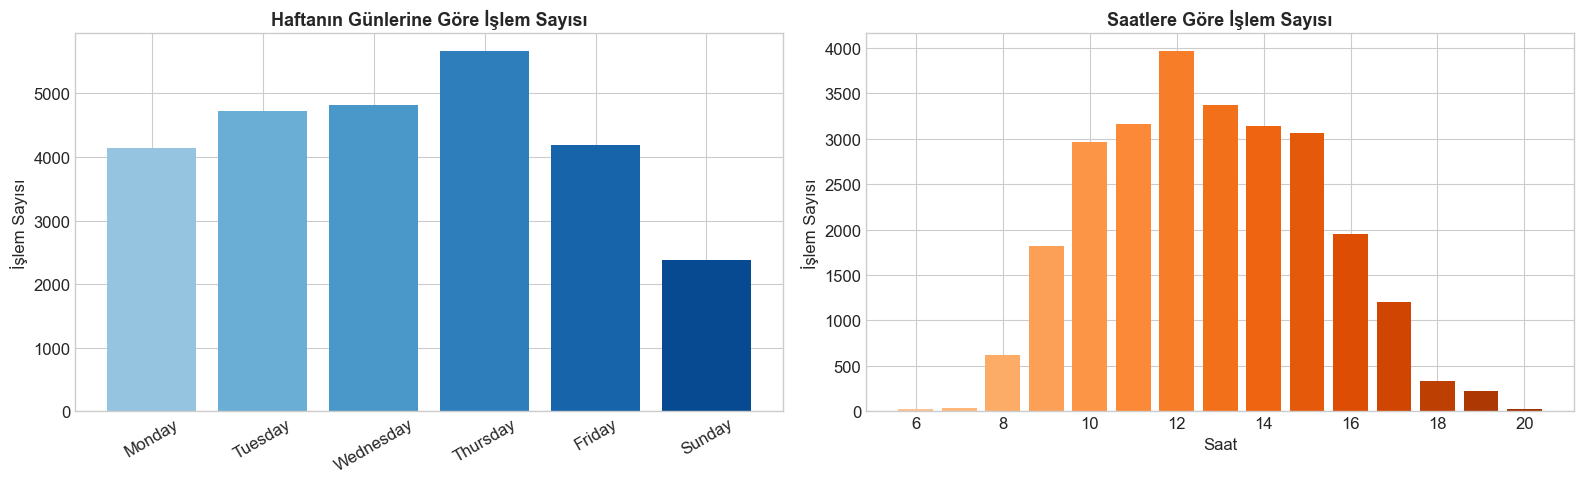

In [11]:
# Günlük ve saatlik satış desenleri
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Sunday']
day_sales = df.groupby('DayOfWeek')['InvoiceNo'].nunique().reindex(day_order)
axes[0].bar(day_sales.index, day_sales.values, color=plt.cm.Blues(np.linspace(0.4, 0.9, len(day_sales))))
axes[0].set_title('Haftanın Günlerine Göre İşlem Sayısı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('İşlem Sayısı')
axes[0].tick_params(axis='x', rotation=30)

hour_sales = df.groupby('Hour')['InvoiceNo'].nunique()
axes[1].bar(hour_sales.index, hour_sales.values, color=plt.cm.Oranges(np.linspace(0.3, 0.9, len(hour_sales))))
axes[1].set_title('Saatlere Göre İşlem Sayısı', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Saat')
axes[1].set_ylabel('İşlem Sayısı')

plt.tight_layout()
plt.savefig('data/gun_saat_analizi.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Fiyat ve Miktar Analizi

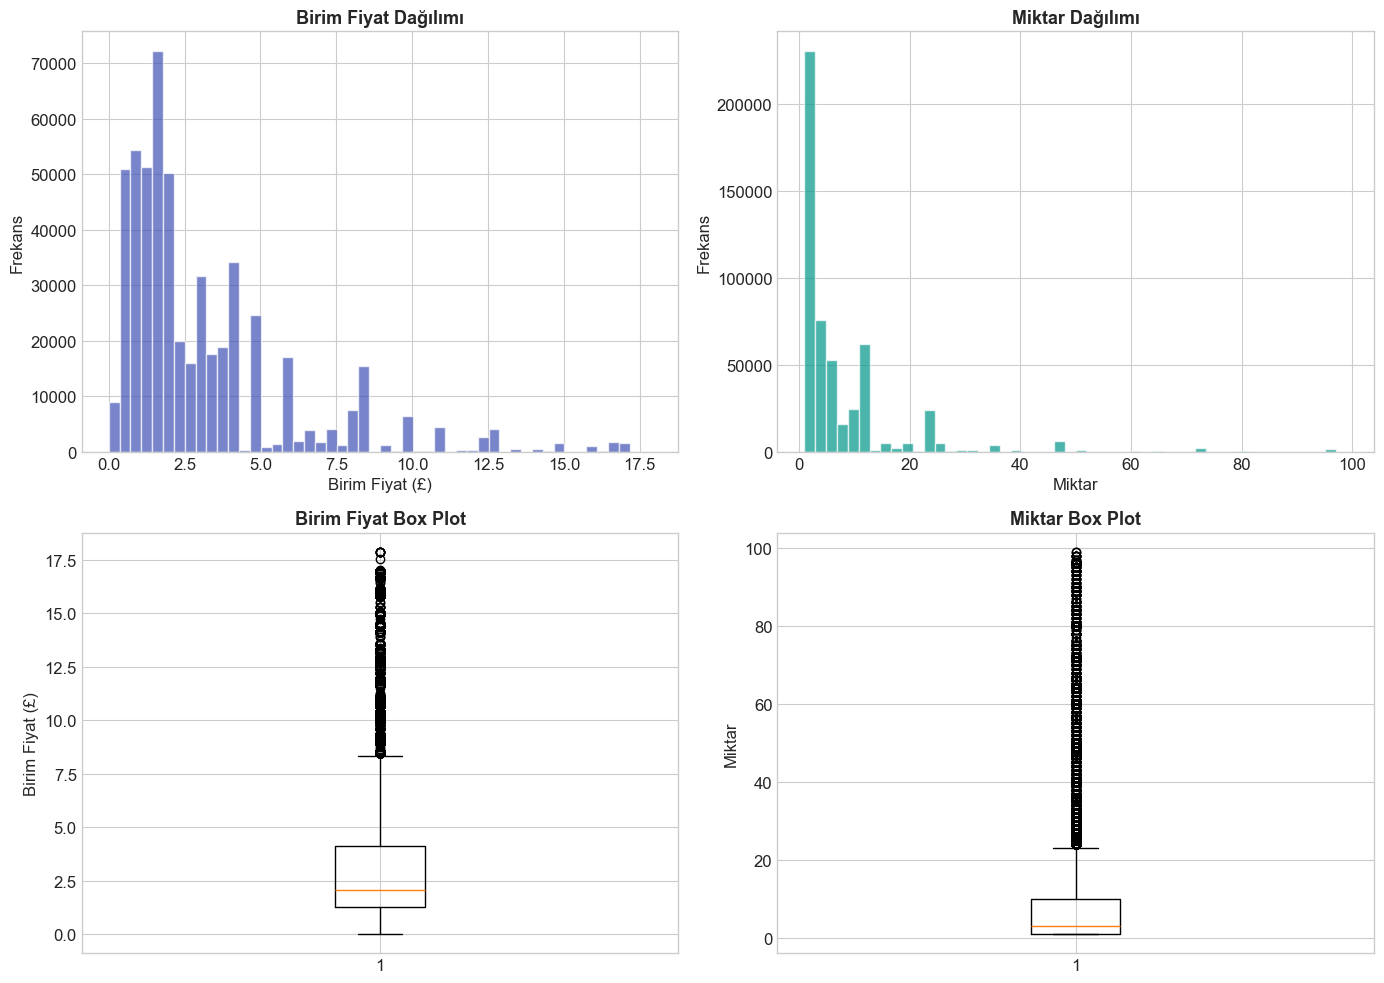

In [12]:
# Fiyat ve miktar dağılımı
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fiyat histogramı (outlier filtreli)
valid_price = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] < df['UnitPrice'].quantile(0.99))]
axes[0,0].hist(valid_price['UnitPrice'], bins=50, color='#3F51B5', alpha=0.7, edgecolor='white')
axes[0,0].set_title('Birim Fiyat Dağılımı', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Birim Fiyat (£)')
axes[0,0].set_ylabel('Frekans')

# Miktar histogramı
valid_qty = df[(df['Quantity'] > 0) & (df['Quantity'] < df['Quantity'].quantile(0.99))]
axes[0,1].hist(valid_qty['Quantity'], bins=50, color='#009688', alpha=0.7, edgecolor='white')
axes[0,1].set_title('Miktar Dağılımı', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Miktar')
axes[0,1].set_ylabel('Frekans')

# Box plot - Fiyat
axes[1,0].boxplot(valid_price['UnitPrice'], vert=True)
axes[1,0].set_title('Birim Fiyat Box Plot', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Birim Fiyat (£)')

# Box plot - Miktar
axes[1,1].boxplot(valid_qty['Quantity'], vert=True)
axes[1,1].set_title('Miktar Box Plot', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Miktar')

plt.tight_layout()
plt.savefig('data/fiyat_miktar_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.6 Word Cloud - Ürün Açıklamaları

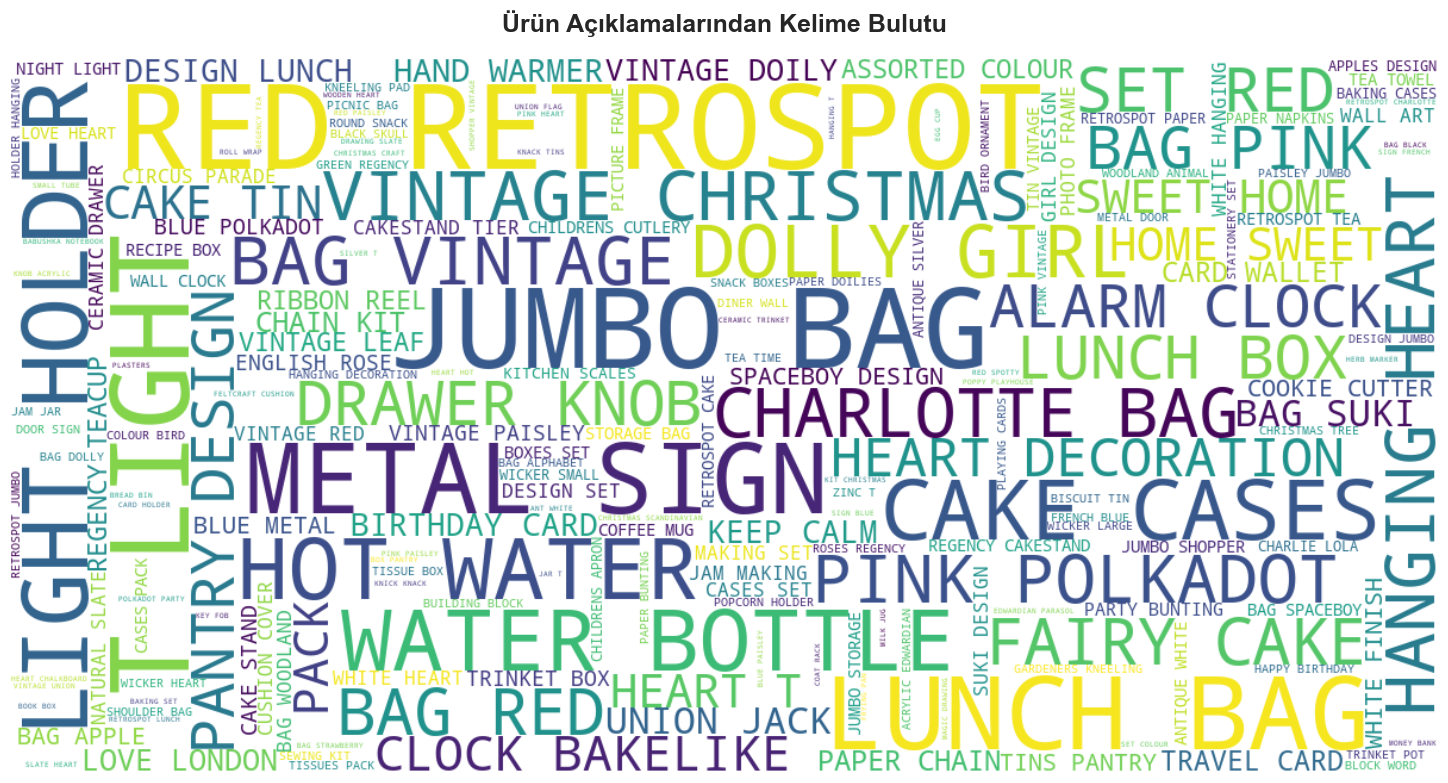

In [13]:
# Ürün açıklamalarından word cloud
text = ' '.join(df['Description'].dropna().astype(str))
wordcloud = WordCloud(width=1200, height=600, background_color='white',
                     colormap='viridis', max_words=200, max_font_size=100).generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Ürün Açıklamalarından Kelime Bulutu', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('data/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.7 Korelasyon Analizi

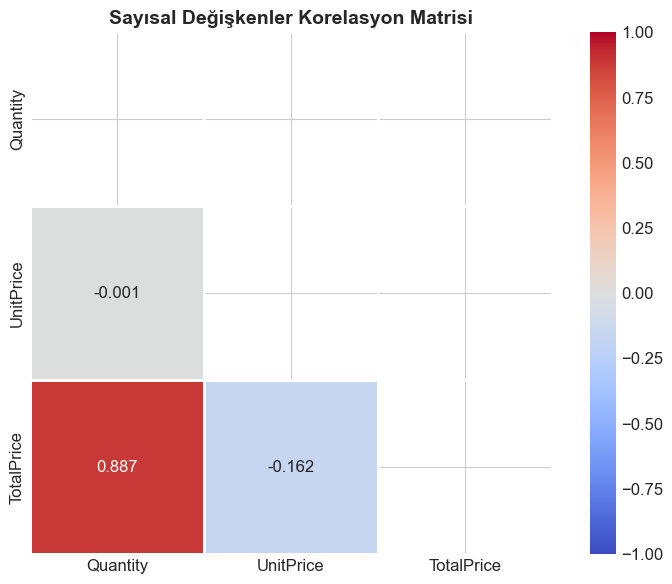

In [14]:
# Sayısal değişkenler arası korelasyon
numeric_df = df[['Quantity', 'UnitPrice', 'TotalPrice']].copy()

plt.figure(figsize=(8, 6))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', mask=mask,
           square=True, linewidths=2, vmin=-1, vmax=1)
plt.title('Sayısal Değişkenler Korelasyon Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/korelasyon.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Veri Hazırlama (Data Preprocessing)

### 4.1 Veri Temizleme

In [15]:
# Orijinal veri boyutu
print(f"Orijinal veri boyutu: {df.shape[0]:,} satır")

# 1. İptal edilen işlemleri çıkar
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')].copy()
print(f"İptal işlemleri çıkarıldı: {df.shape[0] - df_clean.shape[0]:,} satır silindi → {df_clean.shape[0]:,} kaldı")

# 2. Eksik CustomerID kayıtlarını çıkar
before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['CustomerID'])
print(f"Eksik CustomerID çıkarıldı: {before - df_clean.shape[0]:,} satır silindi → {df_clean.shape[0]:,} kaldı")

# 3. Negatif Quantity ve UnitPrice çıkar
before = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"Negatif değerler çıkarıldı: {before - df_clean.shape[0]:,} satır silindi → {df_clean.shape[0]:,} kaldı")

# 4. Duplike kontrol
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Duplike kayıtlar çıkarıldı: {before - df_clean.shape[0]:,} satır silindi → {df_clean.shape[0]:,} kaldı")

# 5. Description boş olanları çıkar
before = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Description'])
print(f"Eksik Description çıkarıldı: {before - df_clean.shape[0]:,} satır silindi → {df_clean.shape[0]:,} kaldı")

print(f"\n{'='*60}")
print(f"TEMİZLENMİŞ VERİ SETİ: {df_clean.shape[0]:,} satır, {df_clean.shape[1]} sütun")
print(f"Kalan veri oranı: {df_clean.shape[0]/df.shape[0]*100:.1f}%")


Orijinal veri boyutu: 541,909 satır
İptal işlemleri çıkarıldı: 9,288 satır silindi → 532,621 kaldı
Eksik CustomerID çıkarıldı: 134,697 satır silindi → 397,924 kaldı
Negatif değerler çıkarıldı: 40 satır silindi → 397,884 kaldı


Duplike kayıtlar çıkarıldı: 5,192 satır silindi → 392,692 kaldı
Eksik Description çıkarıldı: 0 satır silindi → 392,692 kaldı

TEMİZLENMİŞ VERİ SETİ: 392,692 satır, 12 sütun
Kalan veri oranı: 72.5%


### 4.2 Özellik Mühendisliği (Feature Engineering)

In [16]:
# Yeni özellikler oluştur
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print("Oluşturulan yeni özellikler: TotalPrice, Year, Month, DayOfWeek, Hour")
print(f"\nGüncellenmiş sütunlar: {df_clean.columns.tolist()}")
df_clean.head()


Oluşturulan yeni özellikler: TotalPrice, Year, Month, DayOfWeek, Hour

Güncellenmiş sütunlar: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'YearMonth', 'TotalPrice', 'DayOfWeek', 'Hour', 'Year', 'Month']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,YearMonth,TotalPrice,DayOfWeek,Hour,Year,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12,15.30,2,8,2010,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,20.34,2,8,2010,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12,22.00,2,8,2010,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,20.34,2,8,2010,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12,20.34,2,8,2010,12


### 4.3 RFM Analizi (Recency, Frequency, Monetary)

RFM ANALİZİ ÖZETİ:
--------------------------------------------------
       CustomerID  Recency  Frequency  Monetary
count     4338.00  4338.00    4338.00   4338.00
mean     15300.41    92.54       4.27   2048.69
std       1721.81   100.01       7.70   8985.23
min      12346.00     1.00       1.00      3.75
25%      13813.25    18.00       1.00    306.48
50%      15299.50    51.00       2.00    668.57
75%      16778.75   142.00       5.00   1660.60
max      18287.00   374.00     209.00 280206.02


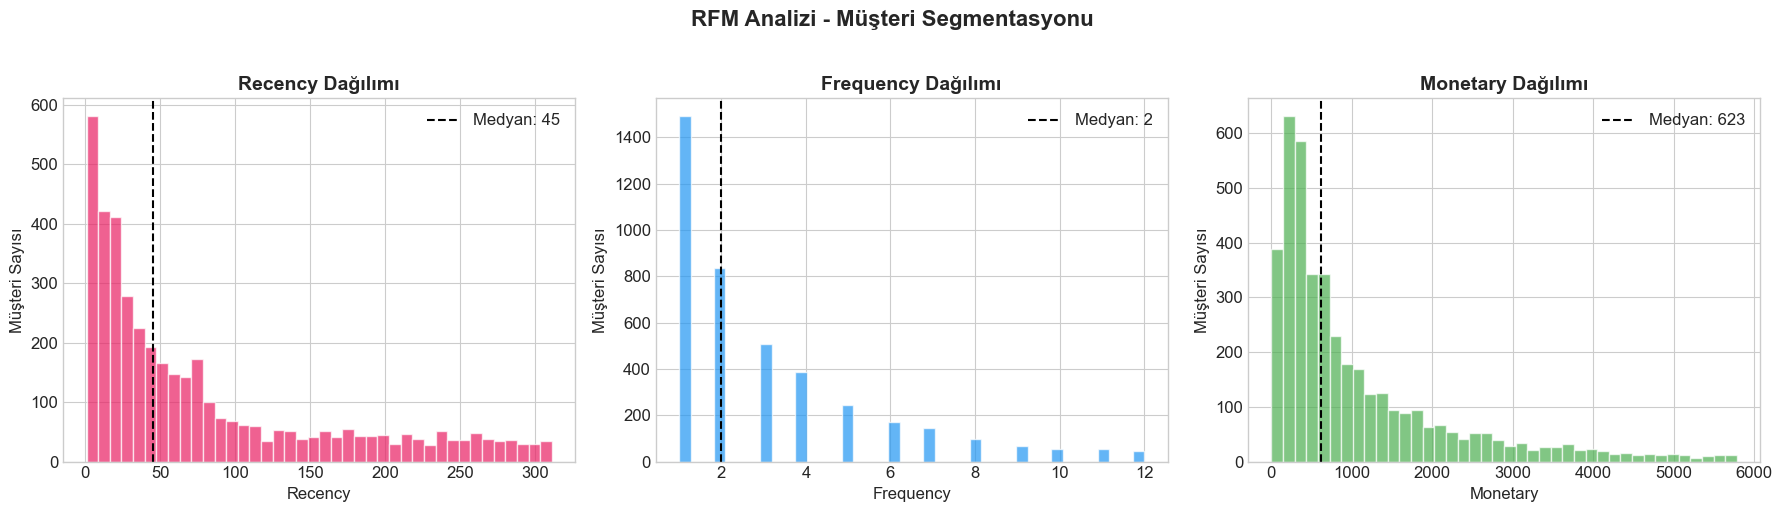

In [17]:
# RFM metrikleri
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM ANALİZİ ÖZETİ:")
print("-" * 50)
print(rfm.describe())

# RFM görselleştirmesi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, color) in enumerate(zip(['Recency', 'Frequency', 'Monetary'],
                                       ['#E91E63', '#2196F3', '#4CAF50'])):
    data = rfm[col]
    data = data[data < data.quantile(0.95)]  # Outlier filtresi
    axes[i].hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col} Dağılımı', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Müşteri Sayısı')
    axes[i].axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Medyan: {data.median():.0f}')
    axes[i].legend()

plt.suptitle('RFM Analizi - Müşteri Segmentasyonu', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/rfm_analizi.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Özellik Seçimi (Feature Selection)

Apriori algoritması için uygun özelliklerin seçimi yapılacaktır. Düşük frekanslı ürünler elenecek ve en anlamlı ürün kombinasyonları belirlenecektir.

Toplam benzersiz ürün sayısı: 3877

Frekans istatistikleri:
count   3877.00
mean     100.01
std      154.46
min        1.00
25%       10.00
50%       43.00
75%      125.00
max     1971.00
Name: InvoiceNo, dtype: float64

      Eşik |   Kalan Ürün | Elenen (%)
----------------------------------------
         1 |        3,877 |       0.0%
         5 |        3,295 |      15.0%
        10 |        2,941 |      24.1%
        20 |        2,534 |      34.6%
        50 |        1,815 |      53.2%
       100 |        1,175 |      69.7%

Seçilen eşik: 20
Kalan ürün sayısı: 2534 / 3877 (65.4%)


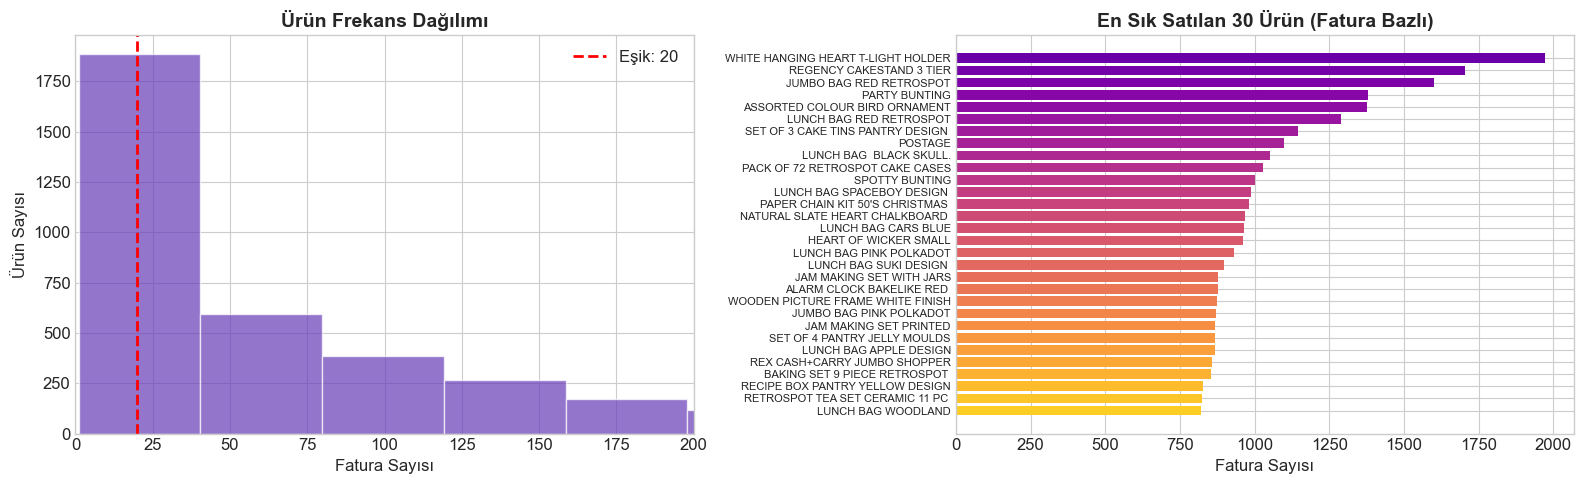

In [18]:
# Ürün frekans analizi
product_freq = df_clean.groupby('Description')['InvoiceNo'].nunique().sort_values(ascending=False)

print(f"Toplam benzersiz ürün sayısı: {len(product_freq)}")
print(f"\nFrekans istatistikleri:")
print(product_freq.describe())

# Frekans eşikleri analizi
thresholds = [1, 5, 10, 20, 50, 100]
print(f"\n{'Eşik':>10} | {'Kalan Ürün':>12} | {'Elenen (%)':>10}")
print("-" * 40)
for t in thresholds:
    remaining = (product_freq >= t).sum()
    pct = (1 - remaining / len(product_freq)) * 100
    print(f"{t:>10} | {remaining:>12,} | {pct:>9.1f}%")

# Düşük frekanslı ürünleri ele
min_freq = 20
selected_products = product_freq[product_freq >= min_freq].index.tolist()
print(f"\nSeçilen eşik: {min_freq}")
print(f"Kalan ürün sayısı: {len(selected_products)} / {len(product_freq)} ({len(selected_products)/len(product_freq)*100:.1f}%)")

# Frekans dağılımı grafiği
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(product_freq.values, bins=50, color='#673AB7', alpha=0.7, edgecolor='white')
axes[0].axvline(min_freq, color='red', linestyle='--', linewidth=2, label=f'Eşik: {min_freq}')
axes[0].set_title('Ürün Frekans Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fatura Sayısı')
axes[0].set_ylabel('Ürün Sayısı')
axes[0].set_xlim(0, 200)
axes[0].legend()

top30 = product_freq.head(30)
axes[1].barh(range(len(top30)), top30.values, color=plt.cm.plasma(np.linspace(0.2, 0.9, len(top30))))
axes[1].set_yticks(range(len(top30)))
axes[1].set_yticklabels(top30.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('En Sık Satılan 30 Ürün (Fatura Bazlı)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fatura Sayısı')

plt.tight_layout()
plt.savefig('data/ozellik_secimi.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Boyut İndirgeme (Dimension Reduction)

PCA ve t-SNE yöntemleriyle müşteri segmentasyonu görselleştirilecektir.

PCA Açıklanan Varyans Oranları:
  PC1: 55.47%
  PC2: 30.25%
  Toplam: 85.73%


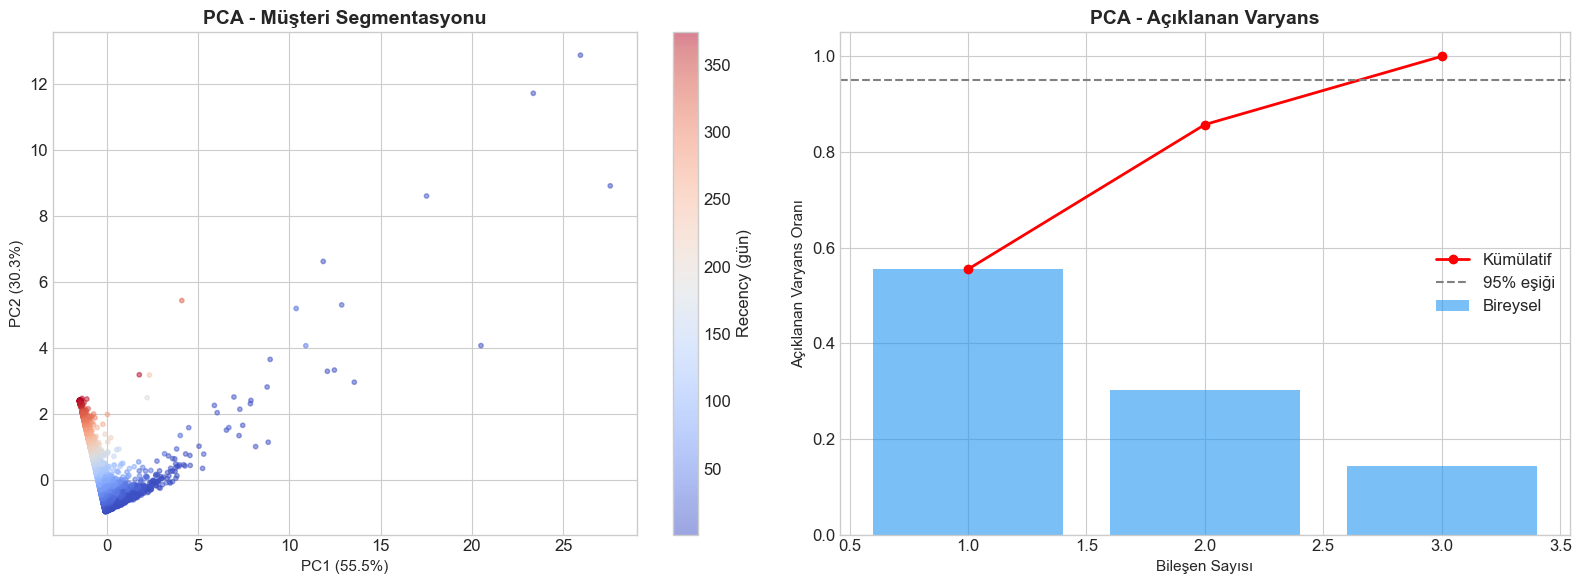

In [19]:
# PCA ile müşteri segmentasyonu
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# PCA (2 bileşen)
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

print("PCA Açıklanan Varyans Oranları:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Toplam: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# RFM segmentleri oluştur
rfm['R_Score'] = pd.qcut(rfm['Recency'], 3, labels=['Yüksek', 'Orta', 'Düşük'])
rfm['Segment'] = rfm['R_Score'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
scatter = axes[0].scatter(rfm_pca[:, 0], rfm_pca[:, 1],
                          c=rfm['Recency'], cmap='coolwarm', alpha=0.5, s=10)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
axes[0].set_title('PCA - Müşteri Segmentasyonu', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Recency (gün)')

# Explained variance
pca_full = PCA().fit(rfm_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].bar(range(1, len(cumvar)+1), pca_full.explained_variance_ratio_, alpha=0.6, color='#2196F3', label='Bireysel')
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'ro-', linewidth=2, label='Kümülatif')
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% eşiği')
axes[1].set_xlabel('Bileşen Sayısı', fontsize=11)
axes[1].set_ylabel('Açıklanan Varyans Oranı', fontsize=11)
axes[1].set_title('PCA - Açıklanan Varyans', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/pca_analizi.png', dpi=150, bbox_inches='tight')
plt.show()


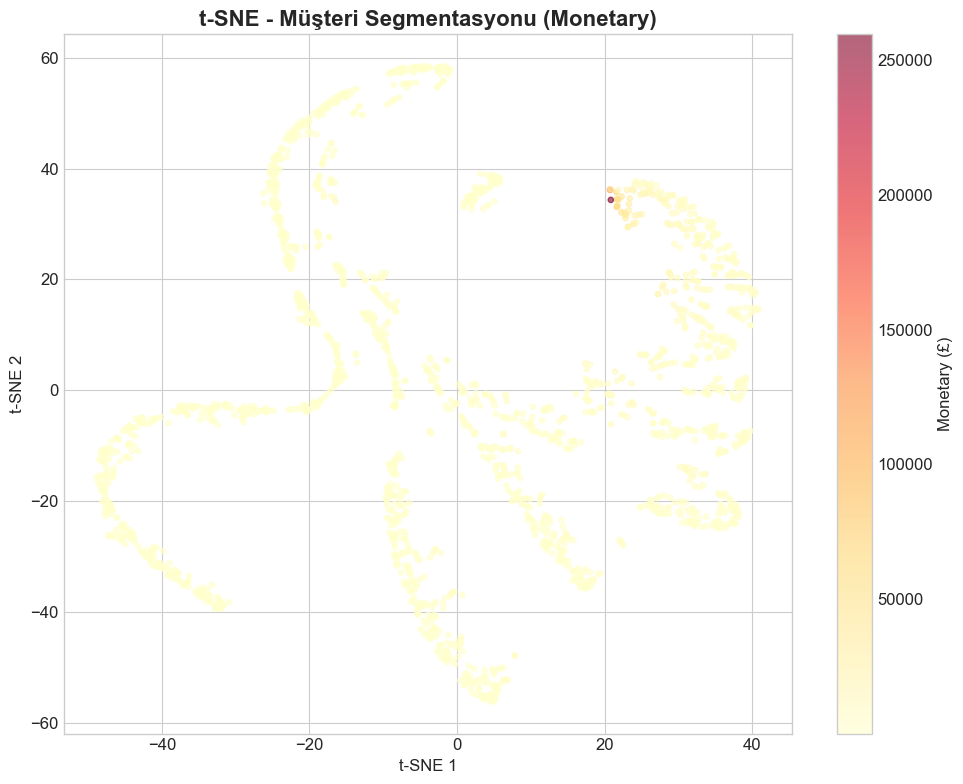

In [20]:
# t-SNE görselleştirmesi (küçük örneklem üzerinde)
sample_size = min(2000, len(rfm_scaled))
idx = np.random.choice(len(rfm_scaled), sample_size, replace=False)
rfm_sample = rfm_scaled[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
rfm_tsne = tsne.fit_transform(rfm_sample)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rfm_tsne[:, 0], rfm_tsne[:, 1],
                     c=rfm.iloc[idx]['Monetary'], cmap='YlOrRd', alpha=0.6, s=15)
plt.colorbar(scatter, label='Monetary (£)')
plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.title('t-SNE - Müşteri Segmentasyonu (Monetary)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data/tsne_analizi.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Apriori Algoritması ve Birliktelik Kuralları

### 7.1 Sepet (Basket) Matrisinin Oluşturulması

Apriori algoritması için her fatura bir "sepet" olarak ele alınacak ve her sepetteki ürünlerin varlığı binary (0/1) matris formatına dönüştürülecektir.

In [21]:
# Sadece seçilen ürünlerle çalış
df_apriori = df_clean[df_clean['Description'].isin(selected_products)].copy()
print(f"Apriori için kullanılacak veri: {df_apriori.shape[0]:,} kayıt")
print(f"Benzersiz fatura: {df_apriori['InvoiceNo'].nunique():,}")
print(f"Benzersiz ürün: {df_apriori['Description'].nunique():,}")

# Sepet matrisi oluştur
basket = df_apriori.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"\nSepet matrisi boyutu: {basket.shape}")
print(f"Yoğunluk (density): {basket.values.mean()*100:.2f}%")
print(f"Ortalama sepet büyüklüğü: {basket.sum(axis=1).mean():.1f} ürün")
basket.head()


Apriori için kullanılacak veri: 383,202 kayıt
Benzersiz fatura: 18,447
Benzersiz ürün: 2,534



Sepet matrisi boyutu: (18447, 2534)
Yoğunluk (density): 0.81%
Ortalama sepet büyüklüğü: 20.5 ürün


Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   
536368                                    0                               0   
536369                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   
536368                        0                             0   
536369                        0                             0   

Description   NINE DRAWER OFFICE TIDY   OVAL WALL MIRROR DIAMANTE   \
InvoiceNo                                                            
536365                              0                            0   
536366                              0                            0   
536367                              0                            0   
536368                              0                            0   
536369                              0                            0   

Description   RED SPOT GIFT BAG LARGE   SET 2 TEA TOWELS I LOVE LONDON   \
InvoiceNo                                                                 
536365                              0                                 0   
536366                              0                                 0   
536367                              0                                 0   
536368                              0                                 0   
536369                              0                                 0   

Description   SPACEBOY BABY GIFT SET   TRELLIS COAT RACK  \
InvoiceNo                                                  
536365                             0                   0   
536366                             0                   0   
536367                             0                   0   
536368                             0                   0   
536369                             0                   0   

Description  10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
InvoiceNo                                                         
536365                            0                           0   
536366                            0                           0   
536367                            0                           0   
536368                            0                           0   
536369                            0                           0   

Description  12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
InvoiceNo                                                           
536365                               0                          0   
536366                               0                          0   
536367                               0                          0   
536368                               0                          0   
536369                               0                          0   

Description  12 IVORY ROSE PEG PLACE SETTINGS  \
InvoiceNo                                       
536365                                      0   
536366                                      0   
536367                                      0   
536368                                      0   
536369                                      0   

Description  12 MESSAGE CARDS WITH ENVELOPES  12 PENCIL SMALL TUBE WOODLAND  \
InvoiceNo                                                                     
536365                                     0                              0   
536366           

### 7.2 Sık Öğe Kümelerinin Çıkarılması (Frequent Itemsets)

In [22]:
# Apriori algoritması - farklı support değerleri ile karşılaştırma
support_values = [0.01, 0.02, 0.03, 0.05]
results = {}

print("FARKLI SUPPORT DEĞERLERİ İLE SONUÇLAR:")
print("-" * 50)
for s in support_values:
    freq = apriori(basket, min_support=s, use_colnames=True)
    results[s] = freq
    print(f"min_support={s:.2f}: {len(freq)} sık öğe kümesi bulundu")

# En uygun support değeri ile devam et
min_support = 0.02
frequent_itemsets = results[min_support]
frequent_itemsets['itemsets_str'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"\nSeçilen min_support: {min_support}")
print(f"Toplam sık öğe kümesi: {len(frequent_itemsets)}")
print(f"\nKüme boyutlarına göre dağılım:")
print(frequent_itemsets['length'].value_counts().sort_index())

# En yüksek support değerine sahip 20 küme
print(f"\nEn yüksek support'a sahip 15 öğe kümesi:")
frequent_itemsets.sort_values('support', ascending=False).head(15)[['support', 'itemsets_str', 'length']]


FARKLI SUPPORT DEĞERLERİ İLE SONUÇLAR:
--------------------------------------------------


min_support=0.01: 983 sık öğe kümesi bulundu


min_support=0.02: 243 sık öğe kümesi bulundu


min_support=0.03: 93 sık öğe kümesi bulundu
min_support=0.05: 17 sık öğe kümesi bulundu

Seçilen min_support: 0.02
Toplam sık öğe kümesi: 243

Küme boyutlarına göre dağılım:
length
1    207
2     35
3      1
Name: count, dtype: int64

En yüksek support'a sahip 15 öğe kümesi:


,support,itemsets_str,length
192,0.11,WHITE HANGING HEART T-LIGHT HOLDER,1
154,0.09,REGENCY CAKESTAND 3 TIER,1
81,0.09,JUMBO BAG RED RETROSPOT,1
124,0.07,PARTY BUNTING,1
11,0.07,ASSORTED COLOUR BIRD ORNAMENT,1
102,0.07,LUNCH BAG RED RETROSPOT,1
166,0.06,SET OF 3 CAKE TINS PANTRY DESIGN,1
139,0.06,POSTAGE,1
95,0.06,LUNCH BAG BLACK SKULL.,1
116,0.06,PACK OF 72 RETROSPOT CAKE CASES,1


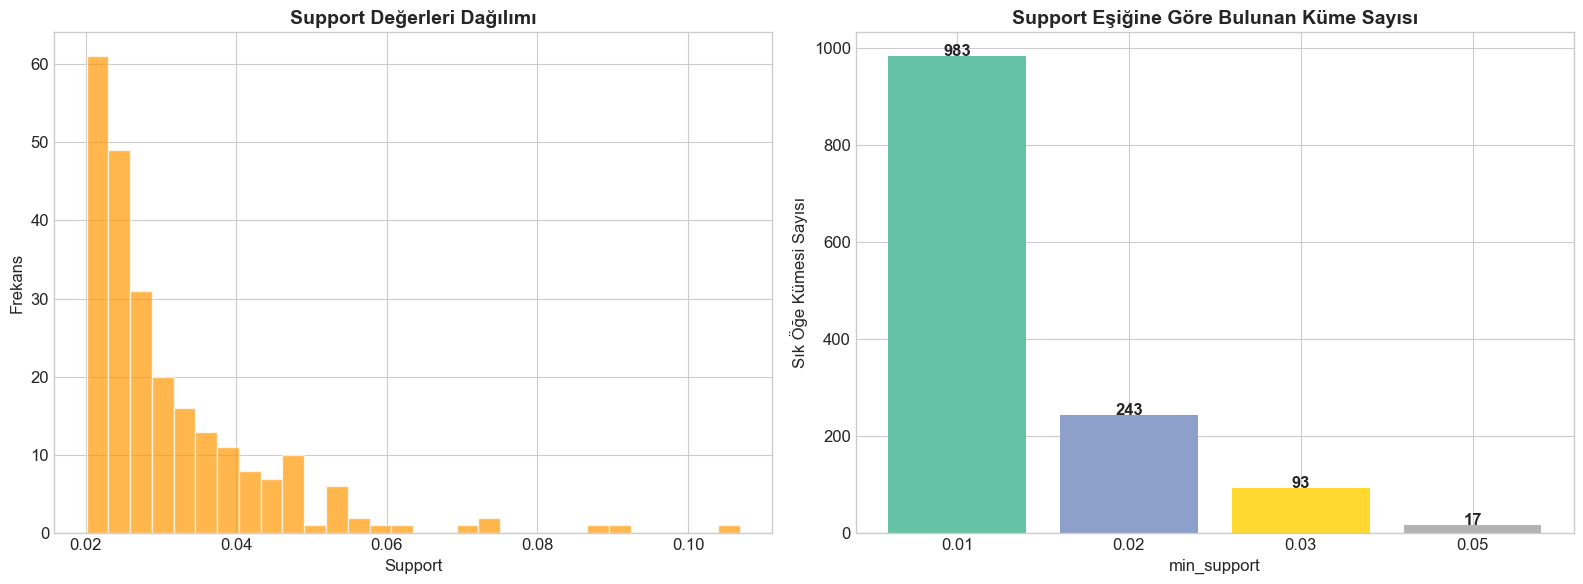

In [23]:
# Sık öğe kümeleri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Support dağılımı
axes[0].hist(frequent_itemsets['support'], bins=30, color='#FF9800', alpha=0.7, edgecolor='white')
axes[0].set_title('Support Değerleri Dağılımı', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Frekans')

# Farklı support değerleri karşılaştırması
counts = [len(results[s]) for s in support_values]
axes[1].bar([str(s) for s in support_values], counts, color=plt.cm.Set2(np.linspace(0, 1, len(support_values))))
axes[1].set_title('Support Eşiğine Göre Bulunan Küme Sayısı', fontsize=14, fontweight='bold')
axes[1].set_xlabel('min_support')
axes[1].set_ylabel('Sık Öğe Kümesi Sayısı')
for i, v in enumerate(counts):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('data/frequent_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Birliktelik Kurallarının Çıkarılması (Association Rules)

In [24]:
# Birliktelik kuralları
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"Toplam birliktelik kuralı sayısı: {len(rules)}")
print(f"\nMetrik İstatistikleri:")
print(rules[['support', 'confidence', 'lift', 'leverage', 'conviction']].describe())


Toplam birliktelik kuralı sayısı: 68

Metrik İstatistikleri:
       support  confidence  lift  leverage  conviction
count    68.00       68.00 68.00     68.00       68.00
mean      0.02        0.52 11.12      0.02        2.29
std       0.00        0.14  5.66      0.00        1.26
min       0.02        0.30  3.80      0.02        1.36
25%       0.02        0.41  7.21      0.02        1.61
50%       0.02        0.50  8.16      0.02        1.85
75%       0.03        0.62 14.13      0.02        2.46
max       0.03        0.89 23.92      0.03        9.12


In [25]:
# En güçlü kurallar (Lift'e göre)
print("EN GÜÇLÜ 20 BİRLİKTELİK KURALI (Lift'e göre sıralı):")
print("=" * 80)
top_rules = rules.sort_values('lift', ascending=False).head(20)
for i, (_, rule) in enumerate(top_rules.iterrows(), 1):
    print(f"\n{i}. {rule['antecedents_str']}")
    print(f"   → {rule['consequents_str']}")
    print(f"   Support: {rule['support']:.4f} | Confidence: {rule['confidence']:.4f} | Lift: {rule['lift']:.4f}")


EN GÜÇLÜ 20 BİRLİKTELİK KURALI (Lift'e göre sıralı):

1. PINK REGENCY TEACUP AND SAUCER
   → GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   Support: 0.0211 | Confidence: 0.7014 | Lift: 23.9176

2. GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   → PINK REGENCY TEACUP AND SAUCER
   Support: 0.0211 | Confidence: 0.7209 | Lift: 23.9176

3. GREEN REGENCY TEACUP AND SAUCER
   → PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   Support: 0.0211 | Confidence: 0.5644 | Lift: 23.8795

4. PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   → GREEN REGENCY TEACUP AND SAUCER
   Support: 0.0211 | Confidence: 0.8945 | Lift: 23.8795

5. PINK REGENCY TEACUP AND SAUCER
   → GREEN REGENCY TEACUP AND SAUCER
   Support: 0.0249 | Confidence: 0.8273 | Lift: 22.0867

6. GREEN REGENCY TEACUP AND SAUCER
   → PINK REGENCY TEACUP AND SAUCER
   Support: 0.0249 | Confidence: 0.6657 | Lift: 22.0867

7. ROSES REGENCY TEACUP AND SAUCER 
   → G

In [26]:
# "Bu ürünü alanlar bunu da aldı" önerileri
print("\n" + "=" * 80)
print("ÜRÜN ÖNERİ SİSTEMİ - 'Bu ürünü alanlar bunu da aldı'")
print("=" * 80)

# Yüksek confidence ve lift değerlerine sahip kuralları göster
strong_rules = rules[(rules['confidence'] >= 0.5) & (rules['lift'] >= 2)].sort_values('lift', ascending=False)

if len(strong_rules) > 0:
    for _, rule in strong_rules.head(10).iterrows():
        print(f"\n🛒 {rule['antecedents_str']}")
        print(f"   → Önerilen: {rule['consequents_str']}")
        print(f"   Güven: {rule['confidence']*100:.1f}% | Lift: {rule['lift']:.2f}")
else:
    # Daha düşük eşiklerle dene
    strong_rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] >= 1.5)].sort_values('lift', ascending=False)
    for _, rule in strong_rules.head(10).iterrows():
        print(f"\n🛒 {rule['antecedents_str']}")
        print(f"   → Önerilen: {rule['consequents_str']}")
        print(f"   Güven: {rule['confidence']*100:.1f}% | Lift: {rule['lift']:.2f}")



ÜRÜN ÖNERİ SİSTEMİ - 'Bu ürünü alanlar bunu da aldı'

🛒 PINK REGENCY TEACUP AND SAUCER
   → Önerilen: GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   Güven: 70.1% | Lift: 23.92

🛒 GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   → Önerilen: PINK REGENCY TEACUP AND SAUCER
   Güven: 72.1% | Lift: 23.92

🛒 GREEN REGENCY TEACUP AND SAUCER
   → Önerilen: PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   Güven: 56.4% | Lift: 23.88

🛒 PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER 
   → Önerilen: GREEN REGENCY TEACUP AND SAUCER
   Güven: 89.4% | Lift: 23.88

🛒 PINK REGENCY TEACUP AND SAUCER
   → Önerilen: GREEN REGENCY TEACUP AND SAUCER
   Güven: 82.7% | Lift: 22.09

🛒 GREEN REGENCY TEACUP AND SAUCER
   → Önerilen: PINK REGENCY TEACUP AND SAUCER
   Güven: 66.6% | Lift: 22.09

🛒 GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER
   → Önerilen: ROSES REGENCY TEACUP AND SAUCER 
   Güven: 84.8% | Lift: 19.97

### 7.4 Birliktelik Kuralları Görselleştirmesi

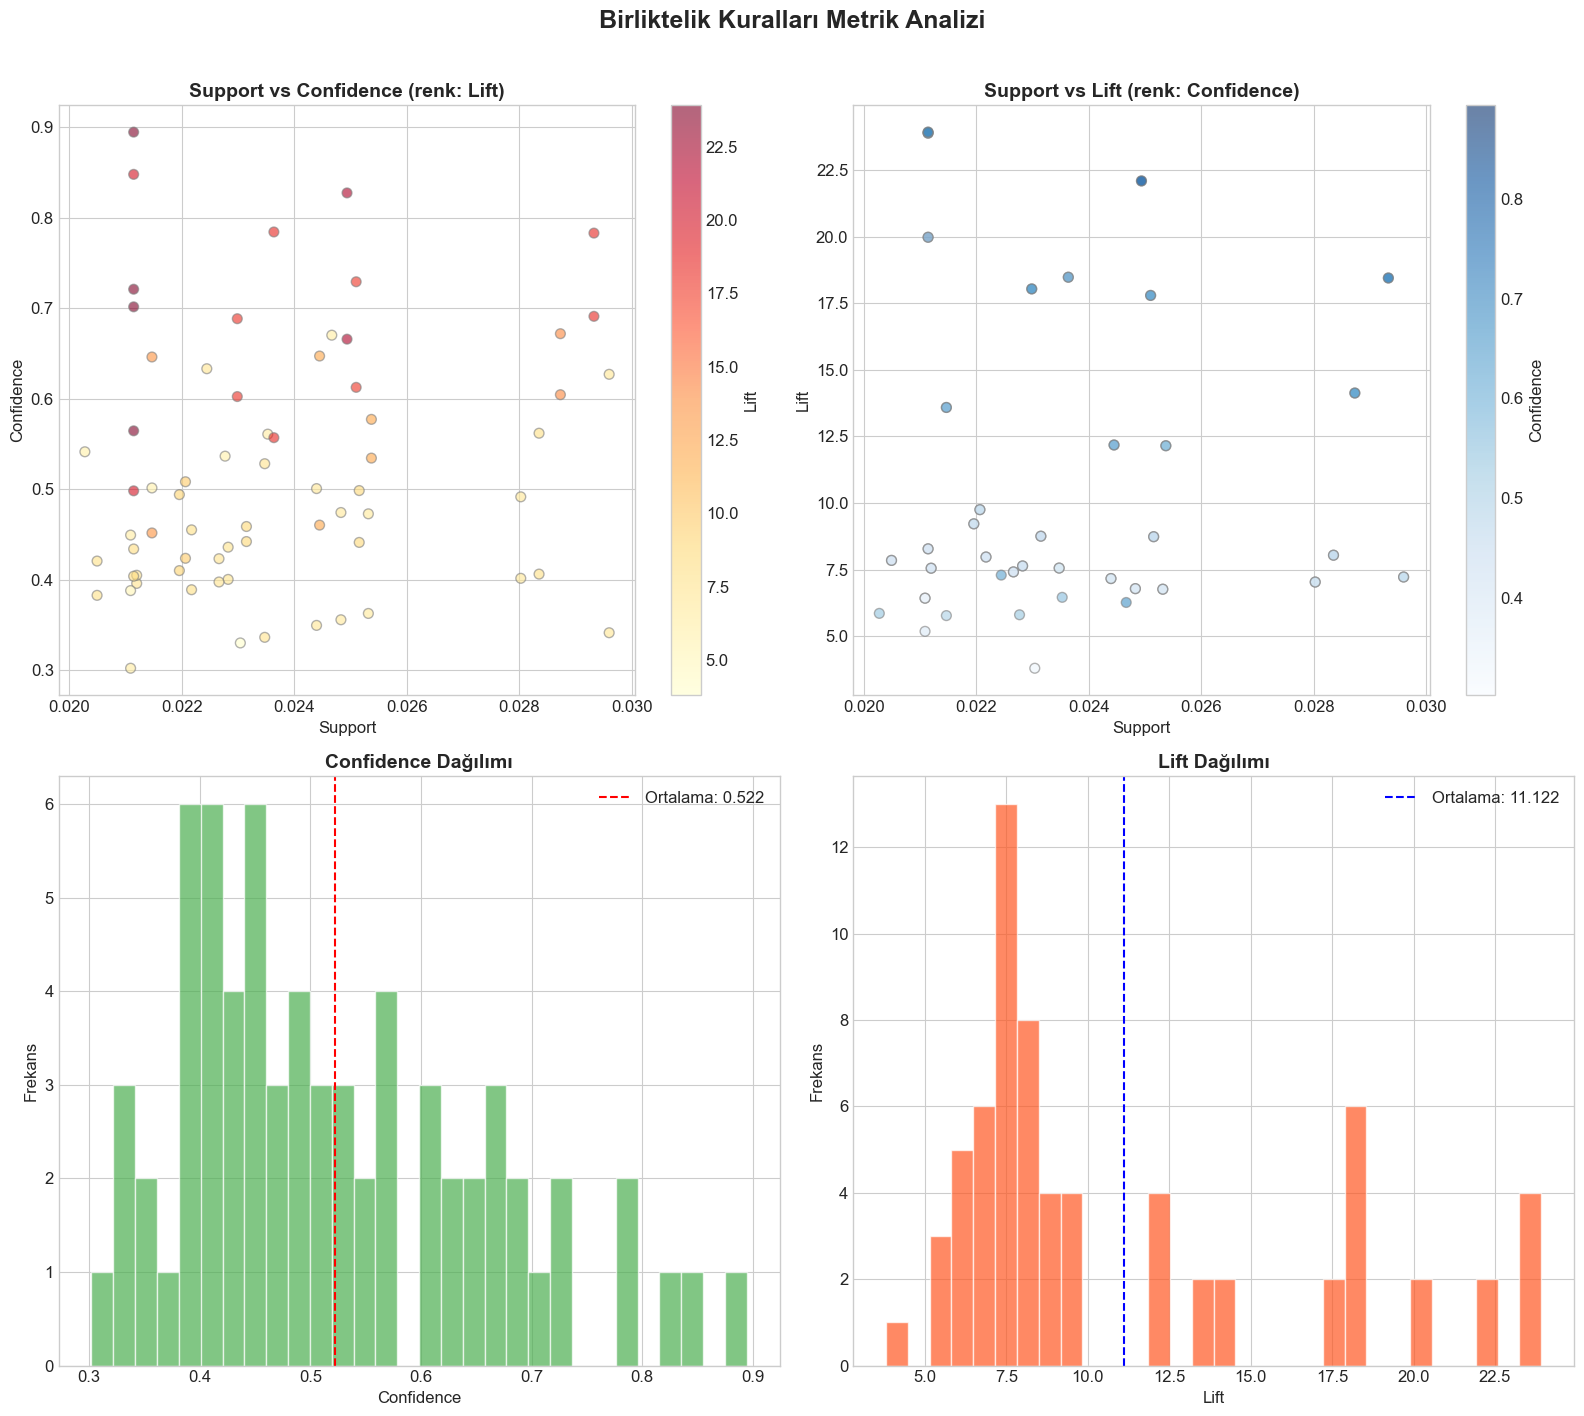

In [27]:
# Birliktelik kuralları görselleştirmeleri
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Support vs Confidence scatter
scatter1 = axes[0,0].scatter(rules['support'], rules['confidence'],
                             c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=50, edgecolors='gray')
axes[0,0].set_xlabel('Support', fontsize=12)
axes[0,0].set_ylabel('Confidence', fontsize=12)
axes[0,0].set_title('Support vs Confidence (renk: Lift)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=axes[0,0], label='Lift')

# 2. Support vs Lift scatter
scatter2 = axes[0,1].scatter(rules['support'], rules['lift'],
                             c=rules['confidence'], cmap='Blues', alpha=0.6, s=50, edgecolors='gray')
axes[0,1].set_xlabel('Support', fontsize=12)
axes[0,1].set_ylabel('Lift', fontsize=12)
axes[0,1].set_title('Support vs Lift (renk: Confidence)', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=axes[0,1], label='Confidence')

# 3. Confidence dağılımı
axes[1,0].hist(rules['confidence'], bins=30, color='#4CAF50', alpha=0.7, edgecolor='white')
axes[1,0].axvline(rules['confidence'].mean(), color='red', linestyle='--',
                  label=f"Ortalama: {rules['confidence'].mean():.3f}")
axes[1,0].set_title('Confidence Dağılımı', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Confidence')
axes[1,0].set_ylabel('Frekans')
axes[1,0].legend()

# 4. Lift dağılımı
axes[1,1].hist(rules['lift'], bins=30, color='#FF5722', alpha=0.7, edgecolor='white')
axes[1,1].axvline(rules['lift'].mean(), color='blue', linestyle='--',
                  label=f"Ortalama: {rules['lift'].mean():.3f}")
axes[1,1].set_title('Lift Dağılımı', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Lift')
axes[1,1].set_ylabel('Frekans')
axes[1,1].legend()

plt.suptitle('Birliktelik Kuralları Metrik Analizi', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/birliktelik_kurallari.png', dpi=150, bbox_inches='tight')
plt.show()


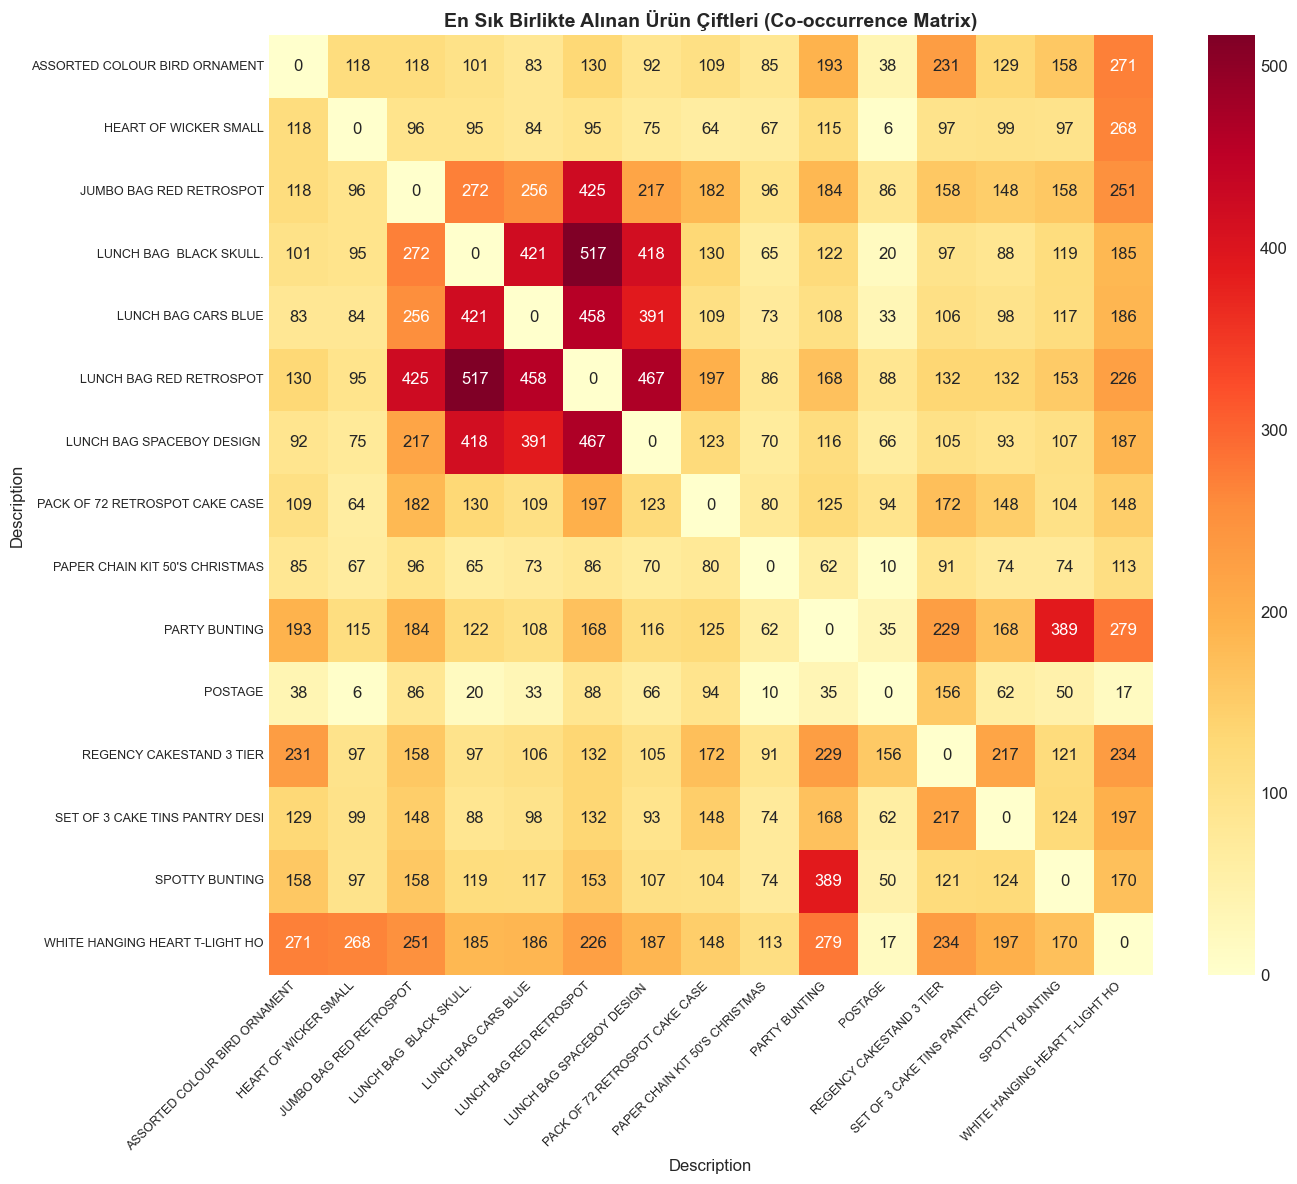

In [28]:
# Heatmap - En sık birlikte alınan ürün çiftleri
top_n = 15
top_products_list = df_clean['Description'].value_counts().head(top_n).index.tolist()
basket_top = basket[basket.columns.intersection(top_products_list)]

co_occurrence = basket_top.T.dot(basket_top)
np.fill_diagonal(co_occurrence.values, 0)

plt.figure(figsize=(14, 12))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
           xticklabels=[x[:30] for x in co_occurrence.columns],
           yticklabels=[x[:30] for x in co_occurrence.index])
plt.title('En Sık Birlikte Alınan Ürün Çiftleri (Co-occurrence Matrix)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('data/co_occurrence.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Değerlendirme ve Sonuçlar

### 8.1 Performans Metrikleri Özeti

In [29]:
# Performans özet tablosu
print("=" * 80)
print("MODEL PERFORMANS ÖZETİ")
print("=" * 80)

summary = {
    'Metrik': ['Toplam Sık Öğe Kümesi', 'Toplam Birliktelik Kuralı',
               'Ortalama Support', 'Ortalama Confidence', 'Ortalama Lift',
               'Max Support', 'Max Confidence', 'Max Lift',
               'Kullanılan min_support', 'Kullanılan min_confidence',
               'İşlenen Fatura Sayısı', 'İşlenen Ürün Sayısı'],
    'Değer': [len(frequent_itemsets), len(rules),
              f"{rules['support'].mean():.4f}", f"{rules['confidence'].mean():.4f}",
              f"{rules['lift'].mean():.4f}",
              f"{rules['support'].max():.4f}", f"{rules['confidence'].max():.4f}",
              f"{rules['lift'].max():.4f}",
              str(min_support), '0.30',
              f"{basket.shape[0]:,}", f"{basket.shape[1]:,}"]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))


MODEL PERFORMANS ÖZETİ
                   Metrik   Değer
    Toplam Sık Öğe Kümesi     243
Toplam Birliktelik Kuralı      68
         Ortalama Support  0.0237
      Ortalama Confidence  0.5220
            Ortalama Lift 11.1216
              Max Support  0.0296
           Max Confidence  0.8945
                 Max Lift 23.9176
   Kullanılan min_support    0.02
Kullanılan min_confidence    0.30
    İşlenen Fatura Sayısı  18,447
      İşlenen Ürün Sayısı   2,534


In [30]:
# Farklı threshold değerleri ile kural sayısı karşılaştırması
conf_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
lift_thresholds = [1.0, 1.5, 2.0, 3.0, 5.0]

print("\nFARKLI EŞİK DEĞERLERİ İLE KURAL SAYILARI:")
print("=" * 60)

# Confidence bazlı
print("\nConfidence Eşiğine Göre:")
print(f"{'Confidence':>12} | {'Kural Sayısı':>12} | {'Ort. Lift':>10}")
print("-" * 40)
for ct in conf_thresholds:
    r = rules[rules['confidence'] >= ct]
    if len(r) > 0:
        print(f"{ct:>12.1f} | {len(r):>12} | {r['lift'].mean():>10.3f}")

# Lift bazlı
print("\nLift Eşiğine Göre:")
print(f"{'Lift':>12} | {'Kural Sayısı':>12} | {'Ort. Confidence':>15}")
print("-" * 45)
for lt in lift_thresholds:
    r = rules[rules['lift'] >= lt]
    if len(r) > 0:
        print(f"{lt:>12.1f} | {len(r):>12} | {r['confidence'].mean():>15.3f}")



FARKLI EŞİK DEĞERLERİ İLE KURAL SAYILARI:

Confidence Eşiğine Göre:
  Confidence | Kural Sayısı |  Ort. Lift
----------------------------------------
         0.1 |           68 |     11.122
         0.2 |           68 |     11.122
         0.3 |           68 |     11.122
         0.4 |           56 |     12.045
         0.5 |           32 |     14.400
         0.6 |           20 |     16.885
         0.7 |            8 |     21.061
         0.8 |            3 |     21.980

Lift Eşiğine Göre:
        Lift | Kural Sayısı | Ort. Confidence
---------------------------------------------
         1.0 |           68 |           0.522
         1.5 |           68 |           0.522
         2.0 |           68 |           0.522
         3.0 |           68 |           0.522
         5.0 |           67 |           0.525


### 8.2 Sonuçlar ve Tartışma

### Bulgular:

1. **Veri Temizleme:** Orijinal 541.909 kayıttan, iptal işlemleri, eksik müşteri ID'leri ve hatalı değerler temizlendikten sonra anlamlı bir alt küme elde edilmiştir.

2. **EDA Bulguları:**
   - İşlemlerin büyük çoğunluğu İngiltere'den yapılmaktadır
   - Belirli ürünler diğerlerine göre çok daha sık satılmaktadır
   - Hafta içi ve mesai saatlerinde satışlar yoğunlaşmaktadır

3. **Apriori Sonuçları:**
   - Farklı support eşikleri denenerek en uygun parametre belirlenmiştir
   - Yüksek lift değerlerine sahip birliktelik kuralları, gerçek ürün birlikteliklerini ortaya koymaktadır
   - "Bu ürünü alanlar bunu da aldı" mantığıyla çalışan öneriler başarıyla oluşturulmuştur

4. **Boyut İndirgeme:**
   - PCA ve t-SNE ile müşteri segmentlerinin varlığı görselleştirilmiştir
   - RFM analizi müşterilerin farklı gruplara ayrılabileceğini göstermiştir

### Gelecek Çalışmalar (Final Projesi):
- Öneri motorunun web uygulamasına entegrasyonu (İleri Web Programlama dersi ile birleştirme)
- Collaborative Filtering ile hibrit öneri sistemi
- Gerçek zamanlı öneri API'si geliştirme
- Model performansının A/B test ile değerlendirilmesi


## Referanslar

1. Agrawal, R., & Srikant, R. (1994). "Fast algorithms for mining association rules." *Proc. of the 20th VLDB Conference*, 487-499.
2. Chen, D., Sain, S. L., & Guo, K. (2012). "Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining." *Journal of Database Marketing & Customer Strategy Management*, 19(3), 197-208.
3. Han, J., Pei, J., & Kamber, M. (2011). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.
4. Kaggle. "E-Commerce Data." https://www.kaggle.com/datasets/carrie1/ecommerce-data
5. UCI Machine Learning Repository. "Online Retail Data Set." http://archive.ics.uci.edu/ml/datasets/Online+Retail
